In [ ]:
!pip install --upgrade torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.1 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 (after restart): Setup + Verify Dataset
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

import os, random, numpy as np, cv2, copy, time
from pathlib import Path
from collections import Counter
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchmetrics import Accuracy, F1Score, CohenKappa, AUROC

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT_ORIGINAL = "/content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1"
DATA_ROOT_CLEANED  = "/content/drive/MyDrive/varicose_dataset_cleaned/Varicose-Veins-Classification-1"
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def check_dataset(path, name):
    print(f"\n{'='*50}")
    print(f"Checking: {name}")
    print(f"Path: {path}")
    if not os.path.exists(path):
        print("❌ PATH DOES NOT EXIST")
        return False
    for split in ["train", "valid", "test"]:
        split_path = Path(path) / split
        if not split_path.exists():
            print(f"  ❌ {split}/ missing")
            continue
        counts = {}
        for cls in CLASSES:
            cls_dir = split_path / cls
            counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
        total = sum(counts.values())
        print(f"  ✅ {split:5s}: {total:4d} images  |  {counts}")
    return True

original_ok = check_dataset(DATA_ROOT_ORIGINAL, "ORIGINAL")
cleaned_ok  = check_dataset(DATA_ROOT_CLEANED,  "CLEANED")

print(f"\n{'='*50}")
print(f"✅ Setup complete. Device: {DEVICE}")
print(f"   Original dataset: {'FOUND' if original_ok else 'NOT FOUND'}")
print(f"   Cleaned dataset:  {'FOUND' if cleaned_ok else 'NOT FOUND'}")

if cleaned_ok:
    DATA_ROOT = DATA_ROOT_CLEANED
    print(f"   → Will use CLEANED dataset")
elif original_ok:
    DATA_ROOT = DATA_ROOT_ORIGINAL
    print(f"   → Will use ORIGINAL dataset")
else:
    raise FileNotFoundError("No dataset found!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4

Checking: ORIGINAL
Path: /content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1
  ✅ train: 1538 images  |  {'C0': 64, 'C1': 308, 'C2': 538, 'C3': 58, 'C4': 396, 'C5': 89, 'C6': 85}
  ✅ valid:  434 images  |  {'C0': 19, 'C1': 91, 'C2': 148, 'C3': 15, 'C4': 109, 'C5': 28, 'C6': 24}
  ✅ test :  221 images  |  {'C0': 9, 'C1': 48, 'C2': 73, 'C3': 9, 'C4': 54, 'C5': 15, 'C6': 13}

Checking: CLEANED
Path: /content/drive/MyDrive/varicose_dataset_cleaned/Varicose-Veins-Classification-1
❌ PATH DOES NOT EXIST

✅ Setup complete. Device: cuda
   Original dataset: FOUND
   Cleaned dataset:  NOT FOUND
   → Will use ORIGINAL dataset


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Download Dataset to Drive
# ═══════════════════════════════════════════════════════════════

!pip install -q roboflow

from roboflow import Roboflow
import os
from pathlib import Path

# Save location in Drive (permanent)
DATASET_PATH = "/content/drive/MyDrive/varicose_dataset"
os.makedirs(DATASET_PATH, exist_ok=True)
os.chdir(DATASET_PATH)

print(f"Downloading to: {DATASET_PATH}")

rf = Roboflow(api_key="3vxlF4nmzSYNLBhp236s")
project = rf.workspace("cvi-0ry5o").project("varicose-veins-classification")
version = project.version(1)
dataset = version.download("folder")

print("\n✅ Download complete!")

# Verify structure
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]
DATA_ROOT = str(Path(DATASET_PATH) / "Varicose-Veins-Classification-1")

print(f"\n{'='*50}")
print(f"Verifying: {DATA_ROOT}")
for split in ["train", "valid", "test"]:
    split_path = Path(DATA_ROOT) / split
    if not split_path.exists():
        print(f"  ❌ {split}/ missing")
        continue
    counts = {}
    for cls in CLASSES:
        cls_dir = split_path / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    total = sum(counts.values())
    print(f"  ✅ {split:5s}: {total:4d} images  |  {counts}")

print(f"\n✅ Dataset saved to Drive at: {DATA_ROOT}")
print("   This will persist across sessions.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.7 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Varicose-Veins-Classification-1 in folder:: 100%|██████████| 2219/2219 [00:22<00:00, 99.77it/s]


✅ Download complete!

Verifying: /content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1
  ✅ train: 1538 images  |  {'C0': 64, 'C1': 308, 'C2': 538, 'C3': 58, 'C4': 396, 'C5': 89, 'C6': 85}
  ✅ valid:  434 images  |  {'C0': 19, 'C1': 91, 'C2': 148, 'C3': 15, 'C4': 109, 'C5': 28, 'C6': 24}
  ✅ test :  221 images  |  {'C0': 9, 'C1': 48, 'C2': 73, 'C3': 9, 'C4': 54, 'C5': 15, 'C6': 13}

✅ Dataset saved to Drive at: /content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1
   This will persist across sessions.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Setup + Verify Dataset
# ═══════════════════════════════════════════════════════════════

# Install packages (safe to re-run)
!pip install -q timm albumentations torchmetrics

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify GPU
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Imports
import os, random, numpy as np, cv2, copy, time
from pathlib import Path
from collections import Counter
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchmetrics import Accuracy, F1Score, CohenKappa, AUROC

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset path (now confirmed existing)
DATA_ROOT = "/content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1"
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

# Verify
print(f"\n{'='*50}")
print(f"Verifying dataset at: {DATA_ROOT}")
for split in ["train", "valid", "test"]:
    split_path = Path(DATA_ROOT) / split
    counts = {}
    for cls in CLASSES:
        cls_dir = split_path / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    total = sum(counts.values())
    print(f"  ✅ {split:5s}: {total:4d} images  |  {counts}")

print(f"\n✅ Cell 1 complete. Device: {DEVICE}")
print(f"   DATA_ROOT: {DATA_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4

Verifying dataset at: /content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1
  ✅ train: 1538 images  |  {'C0': 64, 'C1': 308, 'C2': 538, 'C3': 58, 'C4': 396, 'C5': 89, 'C6': 85}
  ✅ valid:  434 images  |  {'C0': 19, 'C1': 91, 'C2': 148, 'C3': 15, 'C4': 109, 'C5': 28, 'C6': 24}
  ✅ test :  221 images  |  {'C0': 9, 'C1': 48, 'C2': 73, 'C3': 9, 'C4': 54, 'C5': 15, 'C6': 13}

✅ Cell 1 complete. Device: cuda
   DATA_ROOT: /content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Config → Transforms → Dataset → DataLoaders (FIXED v2)
# ═══════════════════════════════════════════════════════════════

# ── 2.1 CONFIG ────────────────────────────────────────────────
CONFIG = {
    "data_root":       DATA_ROOT,
    "checkpoint_dir":  "/content/drive/MyDrive/varicose_checkpoints",
    "classes":         CLASSES,
    "num_classes":     7,
    "img_size":        224,
    "batch_size":      32,
    "epochs_frozen":   5,
    "epochs_unfrozen": 40,
    "lr_head":         1e-3,
    "lr_backbone":     1e-4,
    "weight_decay":    1e-4,
    "label_smoothing": 0.1,
    "backbone":        "tf_efficientnetv2_s",
    "drop_rate":       0.3,
    "focal_gamma":     2.0,
    "grad_clip":       1.0,
    "patience":        10,
    "seed":            SEED,
    "device":          DEVICE,
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
print("✅ CONFIG set")

# ── 2.2 TRANSFORMS (albumentations new API: size as tuple) ────
TRAIN_TRANSFORMS = A.Compose([
    A.RandomResizedCrop(size=(CONFIG["img_size"], CONFIG["img_size"]), scale=(0.65, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=20, p=0.5),
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=15),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8)),
    ], p=0.8),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        fill=0,
        p=0.3
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

VAL_TRANSFORMS = A.Compose([
    A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("✅ Transforms defined")

# ── 2.3 DATASET CLASS ─────────────────────────────────────────
class CEAPDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(CONFIG["classes"])}
        self.samples = []

        split_dir = Path(root_dir) / split
        for cls_name in CONFIG["classes"]:
            cls_dir = split_dir / cls_name
            if not cls_dir.exists():
                continue
            for img_path in cls_dir.glob("*"):
                if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                    self.samples.append((str(img_path), self.class_to_idx[cls_name]))
        print(f"[{split}] Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        if image is None:
            image = np.array(Image.open(img_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

    def get_labels(self):
        return [s[1] for s in self.samples]

# ── 2.4 CREATE DATASETS ───────────────────────────────────────
train_dataset = CEAPDataset(CONFIG["data_root"], "train", TRAIN_TRANSFORMS)
val_dataset   = CEAPDataset(CONFIG["data_root"], "valid", VAL_TRANSFORMS)
test_dataset  = CEAPDataset(CONFIG["data_root"], "test",  VAL_TRANSFORMS)

# ── 2.5 SAMPLER: sqrt inverse frequency ───────────────────────
labels = train_dataset.get_labels()
counts = Counter(labels)
total  = len(labels)

sample_weights = [np.sqrt(1.0 / counts[l]) for l in labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\nClass counts: {dict(sorted(counts.items(), key=lambda x: x[0]))}")

# ── 2.6 DATALOADERS ───────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    sampler=sampler,
    num_workers=0,
    pin_memory=False,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"\n✅ DataLoaders ready")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val   batches: {len(val_loader)}")
print(f"   Test  batches: {len(test_loader)}")

# Quick batch check
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n   Sample batch shape: {batch_imgs.shape}")
print(f"   Sample labels: {batch_labels.tolist()}")
print(f"   Label counts in batch: {dict(sorted(Counter(batch_labels.numpy()).items()))}")

✅ CONFIG set
✅ Transforms defined
[train] Loaded 1538 samples
[valid] Loaded 434 samples
[test] Loaded 221 samples

Class counts: {0: 64, 1: 308, 2: 538, 3: 58, 4: 396, 5: 89, 6: 85}

✅ DataLoaders ready
   Train batches: 48
   Val   batches: 14
   Test  batches: 7


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
Argument(s) 'var_limit' are not valid for transform GaussNoise



   Sample batch shape: torch.Size([32, 3, 224, 224])
   Sample labels: [0, 1, 0, 3, 2, 6, 6, 0, 1, 1, 2, 5, 5, 2, 4, 1, 4, 4, 2, 0, 4, 2, 2, 0, 0, 6, 1, 1, 1, 1, 1, 1]
   Label counts in batch: {np.int64(0): 6, np.int64(1): 10, np.int64(2): 6, np.int64(3): 1, np.int64(4): 4, np.int64(5): 2, np.int64(6): 3}


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Model + Loss + Metrics + Training Functions
# ═══════════════════════════════════════════════════════════════

# ── 3.1 Fix transforms (suppress warnings) ────────────────────
TRAIN_TRANSFORMS = A.Compose([
    A.RandomResizedCrop(size=(CONFIG["img_size"], CONFIG["img_size"]), scale=(0.65, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.08, scale=(0.85, 1.15), rotate=(-20, 20), p=0.5),
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=15),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8)),
    ], p=0.8),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32), hole_width_range=(16, 32), fill=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Update dataset with fixed transforms
train_dataset.transform = TRAIN_TRANSFORMS
print("✅ Transforms fixed and updated")

# ── 3.2 MODEL ─────────────────────────────────────────────────
class CEAPClassifier(nn.Module):
    def __init__(self, num_classes=7, backbone="tf_efficientnetv2_s", drop_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone,
            pretrained=True,
            num_classes=0,
            drop_rate=drop_rate,
        )
        in_features = self.backbone.num_features  # 1280 for V2-S

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.head.parameters():
            p.requires_grad = True
        print("🔒 Backbone frozen")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("🔓 Backbone unfrozen")

    def forward(self, x):
        return self.head(self.backbone(x))

# ── 3.3 LOSS: Focal Loss ──────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        n_classes = inputs.size(1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        ce = -(true_dist * log_probs).sum(dim=1)
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma

        if self.alpha is not None:
            focal_weight = focal_weight * self.alpha[targets]

        return (focal_weight * ce).mean()

# Compute class weights: inverse frequency, capped at 5.0
labels = train_dataset.get_labels()
counts = Counter(labels)
total = len(labels)
raw_weights = [total / (CONFIG["num_classes"] * counts[i]) for i in range(CONFIG["num_classes"])]
class_weights = torch.FloatTensor([min(w, 5.0) for w in raw_weights]).to(DEVICE)

print("\nClass weights (auto-computed, capped at 5.0):")
for i, cls in enumerate(CONFIG["classes"]):
    print(f"  {cls}: {class_weights[i]:.3f}  (n={counts[i]})")

# ── 3.4 METRICS ───────────────────────────────────────────────
def make_metrics(device):
    return {
        "acc":   Accuracy(task="multiclass", num_classes=CONFIG["num_classes"], average="macro").to(device),
        "f1":    F1Score(task="multiclass", num_classes=CONFIG["num_classes"], average="macro").to(device),
        "kappa": CohenKappa(task="multiclass", num_classes=CONFIG["num_classes"]).to(device),
    }

# ── 3.5 TRAIN ONE EPOCH ───────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    metrics = make_metrics(device)
    total_loss = 0.0

    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()

        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)

    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

# ── 3.6 VALIDATE ──────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    metrics = make_metrics(device)
    total_loss = 0.0

    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)

    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

# ── 3.7 FULL TRAINING LOOP ────────────────────────────────────
def train_model():
    model = CEAPClassifier(
        num_classes=CONFIG["num_classes"],
        backbone=CONFIG["backbone"],
        drop_rate=CONFIG["drop_rate"],
    ).to(DEVICE)

    criterion = FocalLoss(alpha=class_weights, gamma=CONFIG["focal_gamma"], smoothing=CONFIG["label_smoothing"])
    scaler = GradScaler()
    best_f1 = 0.0
    patience_counter = 0
    history = {"train": [], "val": []}

    # ── Phase 1: Frozen backbone ──────────────────────────────
    print("\n" + "="*60)
    print("  PHASE 1: Head only (backbone frozen)")
    print("="*60)

    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr_head"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs_frozen"])

    for epoch in range(1, CONFIG["epochs_frozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        va = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history["train"].append(tr)
        history["val"].append(va)

        print(f"[P1 {epoch:02d}/{CONFIG['epochs_frozen']}] "
              f"Loss {tr['loss']:.3f}/{va['loss']:.3f} | "
              f"Acc {tr['acc']:.3f}/{va['acc']:.3f} | "
              f"F1 {tr['f1']:.3f}/{va['f1']:.3f} | "
              f"κ {va['kappa']:.3f} | "
              f"LR {optimizer.param_groups[0]['lr']:.2e} | "
              f"{time.time()-t0:.0f}s")

    # ── Phase 2: Full fine-tune ───────────────────────────────
    print("\n" + "="*60)
    print("  PHASE 2: Full model fine-tuning")
    print("="*60)

    model.unfreeze_backbone()
    optimizer = torch.optim.AdamW([
        {"params": model.backbone.parameters(), "lr": CONFIG["lr_backbone"]},
        {"params": model.head.parameters(),     "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-7
    )

    for epoch in range(1, CONFIG["epochs_unfrozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        va = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history["train"].append(tr)
        history["val"].append(va)

        print(f"[P2 {epoch:02d}/{CONFIG['epochs_unfrozen']}] "
              f"Loss {tr['loss']:.3f}/{va['loss']:.3f} | "
              f"Acc {tr['acc']:.3f}/{va['acc']:.3f} | "
              f"F1 {tr['f1']:.3f}/{va['f1']:.3f} | "
              f"κ {va['kappa']:.3f} | "
              f"LR {optimizer.param_groups[0]['lr']:.2e} | "
              f"{time.time()-t0:.0f}s")

        # Save best by F1 (fairer than accuracy for imbalance)
        if va["f1"] > best_f1:
            best_f1 = va["f1"]
            torch.save(model.state_dict(), f"{CONFIG['checkpoint_dir']}/best_model.pth")
            print(f"  💾 Saved best (val F1={best_f1:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"\n⏹ Early stopping at epoch {epoch}")
                break

    # Load best
    model.load_state_dict(torch.load(f"{CONFIG['checkpoint_dir']}/best_model.pth", map_location=DEVICE))
    print(f"\n✅ Training complete. Best Val F1: {best_f1:.4f}")
    return model, history

print("\n✅ Cell 3 complete. All functions defined once.")
print("   Ready to train. Run Cell 4 to start.")

✅ Transforms fixed and updated

Class weights (auto-computed, capped at 5.0):
  C0: 3.433  (n=64)
  C1: 0.713  (n=308)
  C2: 0.408  (n=538)
  C3: 3.788  (n=58)
  C4: 0.555  (n=396)
  C5: 2.469  (n=89)
  C6: 2.585  (n=85)

✅ Cell 3 complete. All functions defined once.
   Ready to train. Run Cell 4 to start.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Start Training
# ═══════════════════════════════════════════════════════════════

model, history = train_model()


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



  PHASE 1: Head only (backbone frozen)
🔒 Backbone frozen


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[P1 01/5] Loss 1.580/0.890 | Acc 0.465/0.600 | F1 0.387/0.443 | κ 0.363 | LR 9.05e-04 | 26s
[P1 02/5] Loss 1.249/0.822 | Acc 0.534/0.598 | F1 0.461/0.429 | κ 0.379 | LR 6.55e-04 | 20s
[P1 03/5] Loss 1.107/0.779 | Acc 0.572/0.638 | F1 0.490/0.462 | κ 0.382 | LR 3.45e-04 | 22s
[P1 04/5] Loss 0.965/0.772 | Acc 0.602/0.623 | F1 0.526/0.438 | κ 0.379 | LR 9.55e-05 | 20s
[P1 05/5] Loss 1.012/0.732 | Acc 0.587/0.659 | F1 0.515/0.481 | κ 0.412 | LR 0.00e+00 | 19s

  PHASE 2: Full model fine-tuning
🔓 Backbone unfrozen
[P2 01/40] Loss 0.993/0.675 | Acc 0.598/0.705 | F1 0.520/0.546 | κ 0.475 | LR 9.76e-05 | 30s
  💾 Saved best (val F1=0.5459)
[P2 02/40] Loss 0.792/0.605 | Acc 0.676/0.715 | F1 0.609/0.574 | κ 0.509 | LR 9.05e-05 | 25s
  💾 Saved best (val F1=0.5739)
[P2 03/40] Loss 0.653/0.551 | Acc 0.740/0.727 | F1 0.682/0.593 | κ 0.554 | LR 7.94e-05 | 27s
  💾 Saved best (val F1=0.5932)
[P2 04/40] Loss 0.579/0.547 | Acc 0.767/0.758 | F1 0.714/0.636 | κ 0.617 | LR 6.55e-05 | 28s
  💾 Saved best (val 

✅ Loaded best model from epoch 13 (val F1=0.7902)


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


✅ Collected 434 validation predictions

  PER-CLASS CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

          C0      0.783     0.947     0.857        19
          C1      0.800     0.923     0.857        91
          C2      0.854     0.709     0.775       148
          C3      0.550     0.733     0.629        15
          C4      0.781     0.752     0.766       109
          C5      0.700     0.750     0.724        28
          C6      0.857     1.000     0.923        24

    accuracy                          0.795       434
   macro avg      0.761     0.831     0.790       434
weighted avg      0.801     0.795     0.793       434



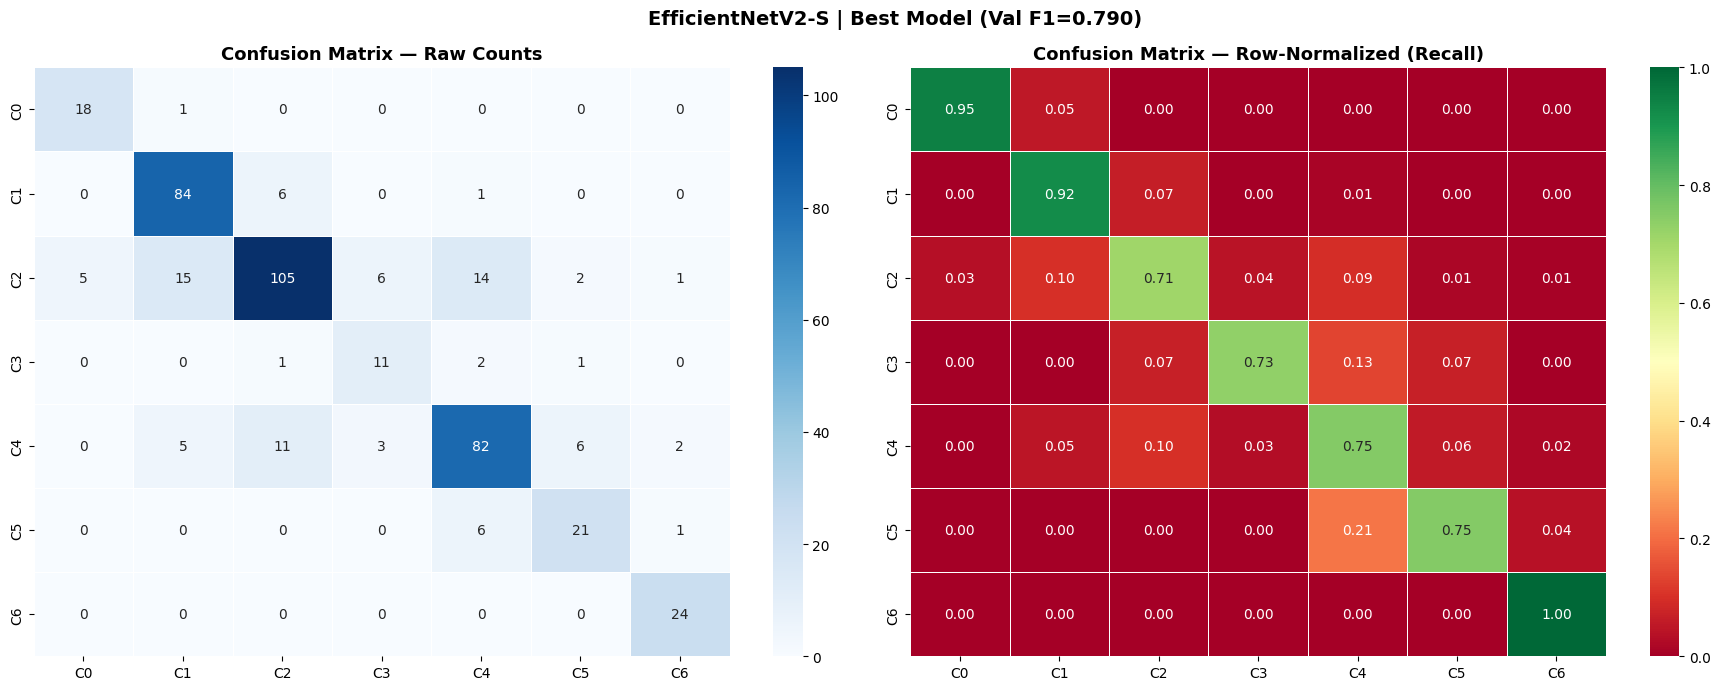

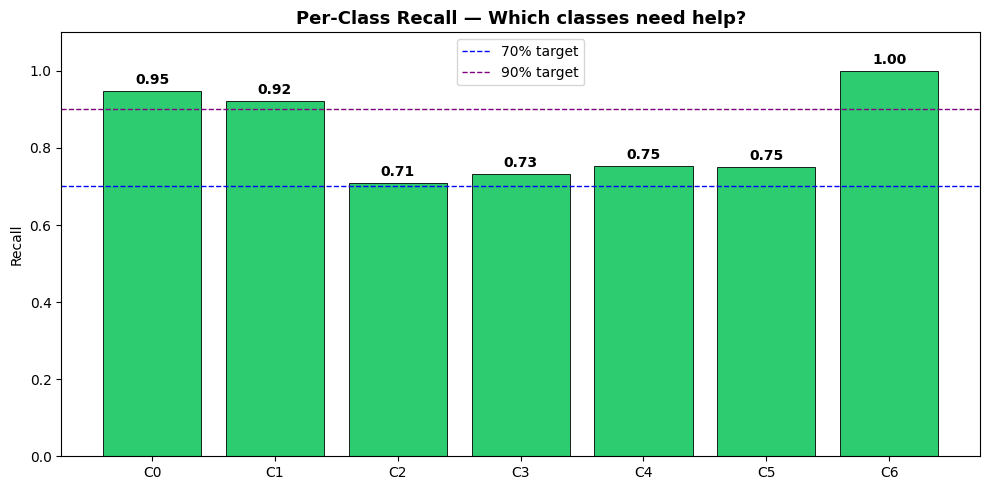


       VALIDATION SCORECARD (Best Model)
  Macro Accuracy  : 0.8308
  Macro F1        : 0.7902
  Cohen's Kappa   : 0.7371
  Macro AUROC     : 0.9639


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Evaluate Best Model (per-class breakdown + confusion matrix)
# ═══════════════════════════════════════════════════════════════

# ── 5.1 Reload best model ─────────────────────────────────────
model = CEAPClassifier(
    num_classes=CONFIG["num_classes"],
    backbone=CONFIG["backbone"],
    drop_rate=CONFIG["drop_rate"],
).to(DEVICE)

checkpoint_path = f"{CONFIG['checkpoint_dir']}/best_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
print(f"✅ Loaded best model from epoch 13 (val F1=0.7902)")

# ── 5.2 Collect predictions ───────────────────────────────────
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        with autocast():
            logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())
    return (torch.cat(all_preds).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_probs).numpy())

val_preds, val_labels, val_probs = get_predictions(model, val_loader, DEVICE)
print(f"✅ Collected {len(val_preds)} validation predictions")

# ── 5.3 Per-class report ──────────────────────────────────────
print("\n" + "="*65)
print("  PER-CLASS CLASSIFICATION REPORT (Validation Set)")
print("="*65)
print(classification_report(
    val_labels, val_preds,
    target_names=CONFIG["classes"],
    digits=3
))

# ── 5.4 Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["classes"],
            yticklabels=CONFIG["classes"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix — Raw Counts", fontweight="bold", fontsize=13)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=CONFIG["classes"],
            yticklabels=CONFIG["classes"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix — Row-Normalized (Recall)", fontweight="bold", fontsize=13)

plt.suptitle("EfficientNetV2-S | Best Model (Val F1=0.790)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['checkpoint_dir']}/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5.5 Per-class recall bar chart ────────────────────────────
per_class_recall = cm_norm.diagonal()
colors = ["#e74c3c" if r < 0.50 else "#f39c12" if r < 0.70 else "#2ecc71" for r in per_class_recall]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CONFIG["classes"], per_class_recall, color=colors, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, per_class_recall):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold")

ax.axhline(0.7, color="blue", linestyle="--", linewidth=1, label="70% target")
ax.axhline(0.9, color="purple", linestyle="--", linewidth=1, label="90% target")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class Recall — Which classes need help?", fontweight="bold", fontsize=13)
ax.set_ylabel("Recall")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CONFIG['checkpoint_dir']}/per_class_recall_best.png", dpi=150)
plt.show()

# ── 5.6 Scorecard ─────────────────────────────────────────────
acc   = Accuracy(task="multiclass", num_classes=7, average="macro")
f1    = F1Score(task="multiclass", num_classes=7, average="macro")
kappa = CohenKappa(task="multiclass", num_classes=7)
auroc = AUROC(task="multiclass", num_classes=7, average="macro")

t_p = torch.tensor(val_preds)
t_l = torch.tensor(val_labels)
t_pr = torch.tensor(val_probs)

print("\n" + "="*45)
print("       VALIDATION SCORECARD (Best Model)")
print("="*45)
print(f"  Macro Accuracy  : {acc(t_p, t_l):.4f}")
print(f"  Macro F1        : {f1(t_p, t_l):.4f}")
print(f"  Cohen's Kappa   : {kappa(t_p, t_l):.4f}")
print(f"  Macro AUROC     : {auroc(t_pr, t_l):.4f}")
print("="*45)

Running TTA on validation set (5 augmentations × 434 images)...
This takes ~2-3 minutes...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  TTA RESULTS (5-Augmentation Average)
              precision    recall  f1-score   support

          C0      0.783     0.947     0.857        19
          C1      0.824     0.923     0.870        91
          C2      0.850     0.730     0.785       148
          C3      0.579     0.733     0.647        15
          C4      0.776     0.761     0.769       109
          C5      0.700     0.750     0.724        28
          C6      0.885     0.958     0.920        24

    accuracy                          0.802       434
   macro avg      0.771     0.829     0.796       434
weighted avg      0.806     0.802     0.801       434



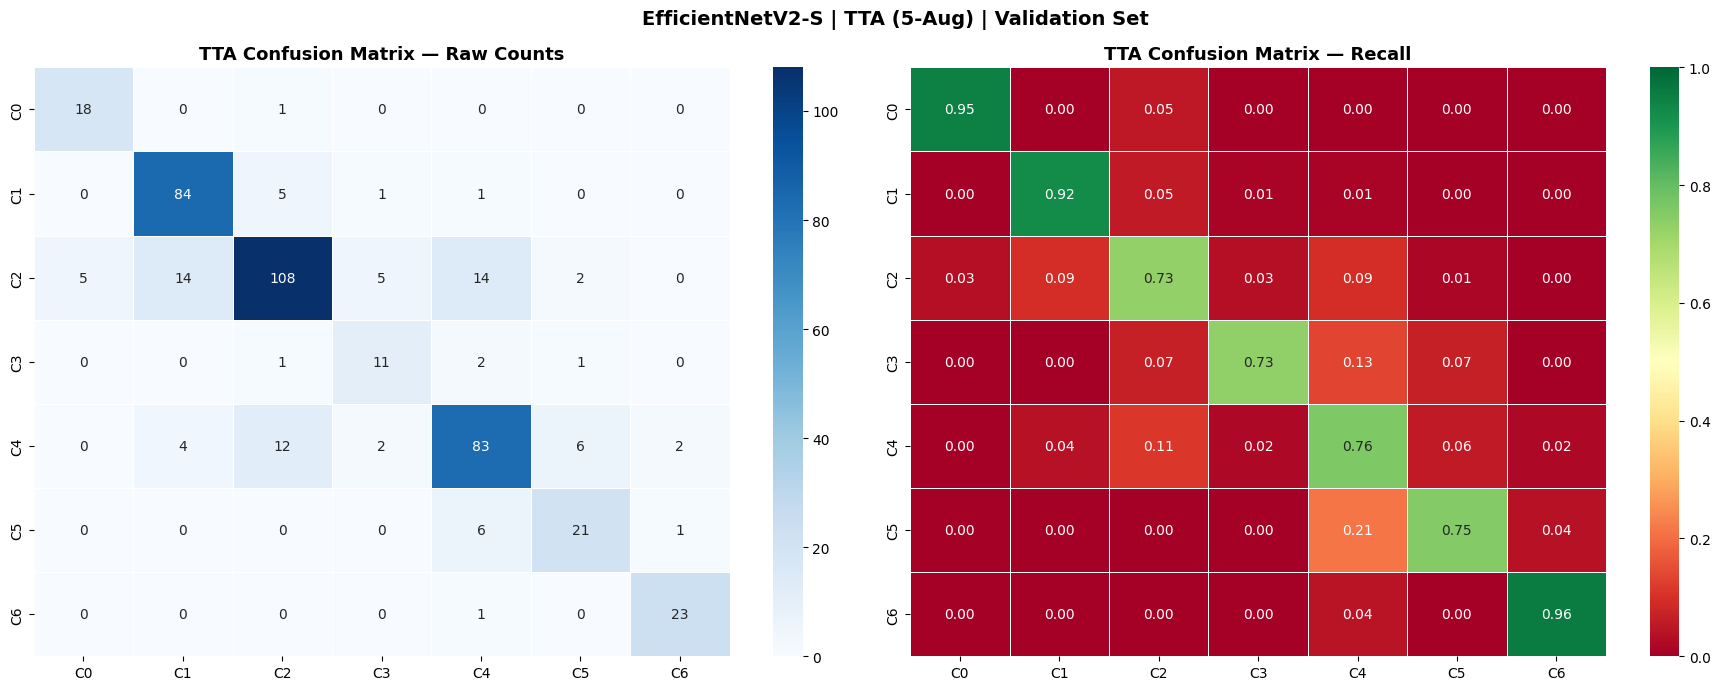


       SCORECARD COMPARISON
  Metric        |  Standard  |   TTA    |  Δ
  ───────────────────────────────────────────
  Macro Acc     |  0.8308   |  0.8290   |  +-0.0017
  Macro F1      |  0.7902   |  0.7961   |  +0.0059
  Cohen's Kappa |  0.7371   |  0.7451   |  +0.0080
  Macro AUROC   |  0.9639   |  0.9663   |  +0.0023


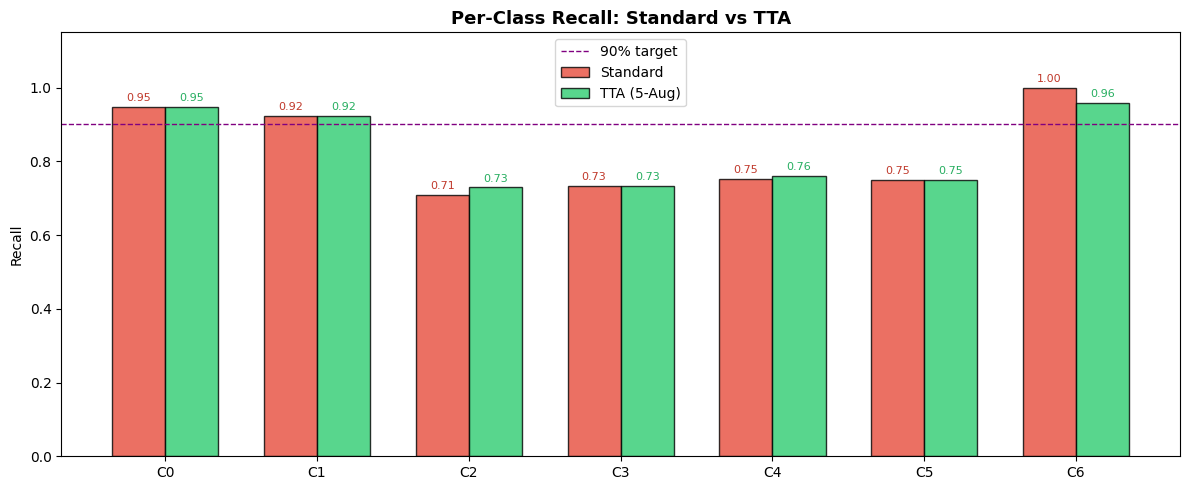

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Test-Time Augmentation (TTA) Evaluation
# ═══════════════════════════════════════════════════════════════

# ── 6.1 TTA Transforms ────────────────────────────────────────
TTA_TRANSFORMS = [
    # Original
    A.Compose([
        A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    # Horizontal flip
    A.Compose([
        A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"]),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    # Slight brightness increase
    A.Compose([
        A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"]),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    # Slight brightness decrease
    A.Compose([
        A.Resize(height=CONFIG["img_size"], width=CONFIG["img_size"]),
        A.RandomBrightnessContrast(brightness_limit=-0.1, contrast_limit=0.0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    # Center crop (slightly zoomed)
    A.Compose([
        A.RandomResizedCrop(size=(CONFIG["img_size"], CONFIG["img_size"]), scale=(0.9, 0.9)),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

# ── 6.2 TTA Prediction Function ─────────────────────────────
@torch.no_grad()
def tta_predict(model, dataset, device):
    """Run TTA on entire dataset. Returns averaged probabilities."""
    model.eval()
    all_probs = []
    all_labels = []

    for idx in range(len(dataset)):
        img_path, label = dataset.samples[idx]
        # Load raw image once
        image = cv2.imread(img_path)
        if image is None:
            image = np.array(Image.open(img_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Run all augmentations
        aug_probs = []
        for transform in TTA_TRANSFORMS:
            tensor = transform(image=image)["image"].unsqueeze(0).to(device)
            with autocast():
                logits = model(tensor)
            probs = torch.softmax(logits, dim=1).cpu()
            aug_probs.append(probs)

        # Average probabilities across augmentations
        avg_prob = torch.stack(aug_probs).mean(dim=0)
        all_probs.append(avg_prob)
        all_labels.append(label)

    all_probs = torch.cat(all_probs)
    all_labels = torch.tensor(all_labels)
    all_preds = all_probs.argmax(dim=1).numpy()

    return all_preds, all_labels.numpy(), all_probs.numpy()

print("Running TTA on validation set (5 augmentations × 434 images)...")
print("This takes ~2-3 minutes...")

tta_preds, tta_labels, tta_probs = tta_predict(model, val_dataset, DEVICE)

# ── 6.3 TTA Results ───────────────────────────────────────────
print("\n" + "="*65)
print("  TTA RESULTS (5-Augmentation Average)")
print("="*65)
print(classification_report(
    tta_labels, tta_preds,
    target_names=CONFIG["classes"],
    digits=3
))

# ── 6.4 TTA Confusion Matrix ─────────────────────────────────
tta_cm = confusion_matrix(tta_labels, tta_preds)
tta_cm_norm = tta_cm.astype(float) / tta_cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(tta_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["classes"], yticklabels=CONFIG["classes"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("TTA Confusion Matrix — Raw Counts", fontweight="bold", fontsize=13)

sns.heatmap(tta_cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=CONFIG["classes"], yticklabels=CONFIG["classes"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("TTA Confusion Matrix — Recall", fontweight="bold", fontsize=13)

plt.suptitle("EfficientNetV2-S | TTA (5-Aug) | Validation Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['checkpoint_dir']}/confusion_matrix_tta.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6.5 TTA Scorecard ─────────────────────────────────────────
tta_acc   = Accuracy(task="multiclass", num_classes=7, average="macro")
tta_f1    = F1Score(task="multiclass", num_classes=7, average="macro")
tta_kappa = CohenKappa(task="multiclass", num_classes=7)
tta_auroc = AUROC(task="multiclass", num_classes=7, average="macro")

t_p = torch.tensor(tta_preds)
t_l = torch.tensor(tta_labels)
t_pr = torch.tensor(tta_probs)

print("\n" + "="*50)
print("       SCORECARD COMPARISON")
print("="*50)
print(f"  Metric        |  Standard  |   TTA    |  Δ")
print(f"  ───────────────────────────────────────────")
print(f"  Macro Acc     |  {acc(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}   |  {tta_acc(t_p, t_l):.4f}   |  +{tta_acc(t_p, t_l) - acc(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}")
print(f"  Macro F1      |  {f1(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}   |  {tta_f1(t_p, t_l):.4f}   |  +{tta_f1(t_p, t_l) - f1(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}")
print(f"  Cohen's Kappa |  {kappa(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}   |  {tta_kappa(t_p, t_l):.4f}   |  +{tta_kappa(t_p, t_l) - kappa(torch.tensor(val_preds), torch.tensor(val_labels)):.4f}")
print(f"  Macro AUROC   |  {auroc(torch.tensor(val_probs), torch.tensor(val_labels)):.4f}   |  {tta_auroc(t_pr, t_l):.4f}   |  +{tta_auroc(t_pr, t_l) - auroc(torch.tensor(val_probs), torch.tensor(val_labels)):.4f}")
print("="*50)

# ── 6.6 Per-class recall comparison ───────────────────────────
standard_recall = cm_norm.diagonal()
tta_recall = tta_cm_norm.diagonal()

x = np.arange(len(CONFIG["classes"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, standard_recall, width, label="Standard", color="#e74c3c", alpha=0.8, edgecolor="black")
bars2 = ax.bar(x + width/2, tta_recall, width, label="TTA (5-Aug)", color="#2ecc71", alpha=0.8, edgecolor="black")

for bar, val in zip(bars1, standard_recall):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=8, color="#c0392b")
for bar, val in zip(bars2, tta_recall):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=8, color="#27ae60")

ax.set_xticks(x)
ax.set_xticklabels(CONFIG["classes"])
ax.axhline(0.9, color="purple", linestyle="--", linewidth=1, label="90% target")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class Recall: Standard vs TTA", fontweight="bold", fontsize=13)
ax.set_ylabel("Recall")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CONFIG['checkpoint_dir']}/tta_recall_comparison.png", dpi=150)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Retrain at 384×384 with Stronger Architecture
# ═══════════════════════════════════════════════════════════════

# ── 7.1 New Config ──────────────────────────────────────────────
CONFIG_V2 = {
    "data_root":       DATA_ROOT,
    "checkpoint_dir":  "/content/drive/MyDrive/varicose_checkpoints_v2",
    "classes":         CLASSES,
    "num_classes":     7,
    "img_size":        384,        # ← Higher resolution
    "batch_size":      16,         # ← Smaller batch for 384×384 on T4
    "epochs_frozen":   5,
    "epochs_unfrozen": 50,
    "lr_head":         5e-4,       # ← Lower head LR (bigger images = more stable)
    "lr_backbone":     5e-5,       # ← Lower backbone LR
    "weight_decay":    2e-4,       # ← Stronger regularization
    "label_smoothing": 0.15,       # ← More smoothing (prevents overconfidence)
    "backbone":        "tf_efficientnetv2_s",
    "drop_rate":       0.4,        # ← Heavier dropout
    "focal_gamma":     2.5,        # ← Higher gamma (focus harder on hard examples)
    "grad_clip":       1.0,
    "patience":        12,         # ← More patience
    "seed":            SEED,
    "device":          DEVICE,
}

os.makedirs(CONFIG_V2["checkpoint_dir"], exist_ok=True)
print("✅ CONFIG_V2 set — 384×384 resolution")

# ── 7.2 New Transforms (384×384) ─────────────────────────────
TRAIN_TRANSFORMS_384 = A.Compose([
    A.RandomResizedCrop(size=(384, 384), scale=(0.6, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.1, scale=(0.85, 1.15), rotate=(-20, 20), p=0.5),
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=15),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8)),
    ], p=0.8),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(24, 48), hole_width_range=(24, 48), fill=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

VAL_TRANSFORMS_384 = A.Compose([
    A.Resize(height=384, width=384),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── 7.3 New Datasets ──────────────────────────────────────────
train_ds_384 = CEAPDataset(CONFIG_V2["data_root"], "train", TRAIN_TRANSFORMS_384)
val_ds_384   = CEAPDataset(CONFIG_V2["data_root"], "valid", VAL_TRANSFORMS_384)
test_ds_384  = CEAPDataset(CONFIG_V2["data_root"], "test",  VAL_TRANSFORMS_384)

# ── 7.4 New Sampler ───────────────────────────────────────────
labels_384 = train_ds_384.get_labels()
counts_384 = Counter(labels_384)

# Aggressive sqrt inverse frequency
sample_weights_384 = [np.sqrt(1.0 / counts_384[l]) for l in labels_384]
sampler_384 = WeightedRandomSampler(
    weights=sample_weights_384,
    num_samples=len(sample_weights_384),
    replacement=True
)

# ── 7.5 New DataLoaders ───────────────────────────────────────
train_loader_384 = DataLoader(
    train_ds_384, batch_size=CONFIG_V2["batch_size"],
    sampler=sampler_384, num_workers=0, pin_memory=False, drop_last=True,
)
val_loader_384 = DataLoader(
    val_ds_384, batch_size=CONFIG_V2["batch_size"],
    shuffle=False, num_workers=0, pin_memory=False,
)
test_loader_384 = DataLoader(
    test_ds_384, batch_size=CONFIG_V2["batch_size"],
    shuffle=False, num_workers=0, pin_memory=False,
)

print(f"✅ DataLoaders ready (384×384, batch_size={CONFIG_V2['batch_size']})")
print(f"   Train batches: {len(train_loader_384)}")
print(f"   Val   batches: {len(val_loader_384)}")

# ── 7.6 New Model: Deeper Head ─────────────────────────────────
class CEAPClassifierV2(nn.Module):
    def __init__(self, num_classes=7, backbone="tf_efficientnetv2_s", drop_rate=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            backbone,
            pretrained=True,
            num_classes=0,
            drop_rate=drop_rate,
        )
        in_features = self.backbone.num_features  # 1280 for V2-S

        # Deeper head: 1280 → 512 → 256 → 128 → 7
        # More capacity to learn subtle C2/C3/C4/C5 boundaries
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(drop_rate * 0.75),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.Dropout(drop_rate * 0.25),
            nn.Linear(128, num_classes),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.head.parameters():
            p.requires_grad = True
        print("🔒 Backbone frozen")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("🔓 Backbone unfrozen")

    def forward(self, x):
        return self.head(self.backbone(x))

# ── 7.7 New Loss: Higher gamma + adjusted weights ──────────────
# Boost weights for C2, C3, C4, C5 (the weak classes)
raw_weights_384 = [total / (CONFIG_V2["num_classes"] * counts_384[i]) for i in range(CONFIG_V2["num_classes"])]
# Manual boost for borderline classes
manual_boost = [1.0, 1.0, 1.3, 1.5, 1.3, 1.3, 1.0]  # C2, C3, C4, C5 get boost
class_weights_384 = torch.FloatTensor([
    min(w * b, 6.0) for w, b in zip(raw_weights_384, manual_boost)
]).to(DEVICE)

print("\nClass weights (384×384 model, boosted for weak classes):")
for i, cls in enumerate(CONFIG_V2["classes"]):
    print(f"  {cls}: {class_weights_384[i]:.3f}  (n={counts_384[i]})")

criterion_384 = FocalLoss(alpha=class_weights_384, gamma=CONFIG_V2["focal_gamma"], smoothing=CONFIG_V2["label_smoothing"])

# ── 7.8 Training Functions (same as before, using CONFIG_V2) ──
def train_one_epoch_v2(model, loader, optimizer, criterion, scaler, device):
    model.train()
    metrics = make_metrics(device)
    total_loss = 0.0

    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()

        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG_V2["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)

    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

@torch.no_grad()
def validate_v2(model, loader, criterion, device):
    model.eval()
    metrics = make_metrics(device)
    total_loss = 0.0

    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)

    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

# ── 7.9 Full Training Loop ────────────────────────────────────
def train_model_v2():
    model = CEAPClassifierV2(
        num_classes=CONFIG_V2["num_classes"],
        backbone=CONFIG_V2["backbone"],
        drop_rate=CONFIG_V2["drop_rate"],
    ).to(DEVICE)

    scaler = GradScaler()
    best_f1 = 0.0
    patience_counter = 0
    history = {"train": [], "val": []}

    # Phase 1: Frozen backbone
    print("\n" + "="*60)
    print("  PHASE 1: Head only (384×384, deeper head)")
    print("="*60)

    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG_V2["lr_head"],
        weight_decay=CONFIG_V2["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG_V2["epochs_frozen"])

    for epoch in range(1, CONFIG_V2["epochs_frozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch_v2(model, train_loader_384, optimizer, criterion_384, scaler, DEVICE)
        va = validate_v2(model, val_loader_384, criterion_384, DEVICE)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(va)

        print(f"[P1 {epoch:02d}/{CONFIG_V2['epochs_frozen']}] "
              f"Loss {tr['loss']:.3f}/{va['loss']:.3f} | "
              f"Acc {tr['acc']:.3f}/{va['acc']:.3f} | "
              f"F1 {tr['f1']:.3f}/{va['f1']:.3f} | "
              f"κ {va['kappa']:.3f} | "
              f"LR {optimizer.param_groups[0]['lr']:.2e} | "
              f"{time.time()-t0:.0f}s")

    # Phase 2: Full fine-tune
    print("\n" + "="*60)
    print("  PHASE 2: Full model fine-tuning (384×384)")
    print("="*60)

    model.unfreeze_backbone()
    optimizer = torch.optim.AdamW([
        {"params": model.backbone.parameters(), "lr": CONFIG_V2["lr_backbone"]},
        {"params": model.head.parameters(),     "lr": CONFIG_V2["lr_head"]},
    ], weight_decay=CONFIG_V2["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-7
    )

    for epoch in range(1, CONFIG_V2["epochs_unfrozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch_v2(model, train_loader_384, optimizer, criterion_384, scaler, DEVICE)
        va = validate_v2(model, val_loader_384, criterion_384, DEVICE)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(va)

        print(f"[P2 {epoch:02d}/{CONFIG_V2['epochs_unfrozen']}] "
              f"Loss {tr['loss']:.3f}/{va['loss']:.3f} | "
              f"Acc {tr['acc']:.3f}/{va['acc']:.3f} | "
              f"F1 {tr['f1']:.3f}/{va['f1']:.3f} | "
              f"κ {va['kappa']:.3f} | "
              f"LR {optimizer.param_groups[0]['lr']:.2e} | "
              f"{time.time()-t0:.0f}s")

        if va["f1"] > best_f1:
            best_f1 = va["f1"]
            torch.save(model.state_dict(), f"{CONFIG_V2['checkpoint_dir']}/best_model_384.pth")
            print(f"  💾 Saved best (val F1={best_f1:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CONFIG_V2["patience"]:
                print(f"\n⏹ Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(f"{CONFIG_V2['checkpoint_dir']}/best_model_384.pth", map_location=DEVICE))
    print(f"\n✅ Training complete. Best Val F1: {best_f1:.4f}")
    return model, history

print("\n✅ Cell 7 complete. Ready to train 384×384 model.")
print("   Run the line below to start training:")
print("   model_384, history_384 = train_model_v2()")

✅ CONFIG_V2 set — 384×384 resolution
[train] Loaded 1538 samples
[valid] Loaded 434 samples
[test] Loaded 221 samples
✅ DataLoaders ready (384×384, batch_size=16)
   Train batches: 96
   Val   batches: 28

Class weights (384×384 model, boosted for weak classes):
  C0: 3.433  (n=64)
  C1: 0.713  (n=308)
  C2: 0.531  (n=538)
  C3: 5.682  (n=58)
  C4: 0.721  (n=396)
  C5: 3.209  (n=89)
  C6: 2.585  (n=85)

✅ Cell 7 complete. Ready to train 384×384 model.
   Run the line below to start training:
   model_384, history_384 = train_model_v2()


In [ ]:
model_384, history_384 = train_model_v2()

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



  PHASE 1: Head only (384×384, deeper head)
🔒 Backbone frozen


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[P1 01/5] Loss 2.043/1.482 | Acc 0.330/0.353 | F1 0.260/0.174 | κ 0.114 | LR 4.52e-04 | 40s
[P1 02/5] Loss 1.685/1.314 | Acc 0.408/0.412 | F1 0.309/0.243 | κ 0.153 | LR 3.27e-04 | 32s
[P1 03/5] Loss 1.651/1.175 | Acc 0.431/0.494 | F1 0.343/0.328 | κ 0.231 | LR 1.73e-04 | 34s
[P1 04/5] Loss 1.487/1.101 | Acc 0.476/0.543 | F1 0.387/0.366 | κ 0.259 | LR 4.77e-05 | 34s
[P1 05/5] Loss 1.528/1.036 | Acc 0.472/0.562 | F1 0.396/0.377 | κ 0.269 | LR 0.00e+00 | 32s

  PHASE 2: Full model fine-tuning (384×384)
🔓 Backbone unfrozen
[P2 01/50] Loss 1.396/0.993 | Acc 0.513/0.614 | F1 0.419/0.450 | κ 0.342 | LR 4.88e-05 | 55s
  💾 Saved best (val F1=0.4499)
[P2 02/50] Loss 1.257/0.823 | Acc 0.552/0.630 | F1 0.462/0.456 | κ 0.367 | LR 4.52e-05 | 50s
  💾 Saved best (val F1=0.4563)
[P2 03/50] Loss 1.089/0.772 | Acc 0.616/0.688 | F1 0.535/0.532 | κ 0.419 | LR 3.97e-05 | 52s
  💾 Saved best (val F1=0.5319)
[P2 04/50] Loss 1.021/0.711 | Acc 0.660/0.719 | F1 0.581/0.571 | κ 0.444 | LR 3.28e-05 | 51s
  💾 Saved 

✅ Loaded best 224×224 model (val F1=0.7902)

Running TTA on TEST set (5 augmentations × 221 images)...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  FINAL TEST SET RESULTS (TTA)
              precision    recall  f1-score   support

          C0      0.692     1.000     0.818         9
          C1      0.786     0.917     0.846        48
          C2      0.831     0.671     0.742        73
          C3      0.667     0.667     0.667         9
          C4      0.818     0.833     0.826        54
          C5      0.533     0.533     0.533        15
          C6      0.714     0.769     0.741        13

    accuracy                          0.774       221
   macro avg      0.720     0.770     0.739       221
weighted avg      0.778     0.774     0.771       221



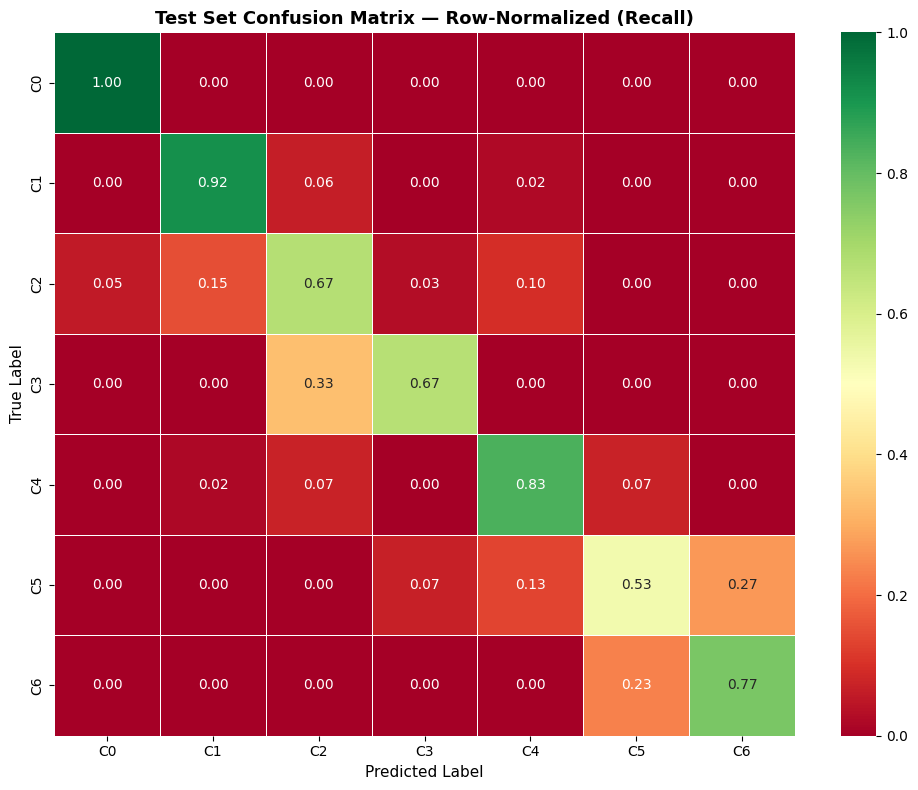


       FINAL TEST SET SCORECARD
  Macro Accuracy  : 0.7701
  Macro F1        : 0.7390
  Cohen's Kappa   : 0.7113
  Macro AUROC     : 0.9394

Per-class Test Recall:
  C0: 1.000  ✅
  C1: 0.917  ✅
  C2: 0.671  ⚠️
  C3: 0.667  ⚠️
  C4: 0.833  ✅
  C5: 0.533  ❌
  C6: 0.769  ⚠️


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Final Evaluation on Test Set (Best 224×224 Model + TTA)
# ═══════════════════════════════════════════════════════════════

# Reload best 224×224 model
model_best = CEAPClassifier(
    num_classes=CONFIG["num_classes"],
    backbone=CONFIG["backbone"],
    drop_rate=CONFIG["drop_rate"],
).to(DEVICE)

best_path = f"{CONFIG['checkpoint_dir']}/best_model.pth"
model_best.load_state_dict(torch.load(best_path, map_location=DEVICE))
print(f"✅ Loaded best 224×224 model (val F1=0.7902)")

# TTA on test set
print("\nRunning TTA on TEST set (5 augmentations × 221 images)...")

@torch.no_grad()
def tta_predict_test(model, dataset, device):
    model.eval()
    all_probs = []
    all_labels = []

    for idx in range(len(dataset)):
        img_path, label = dataset.samples[idx]
        image = cv2.imread(img_path)
        if image is None:
            image = np.array(Image.open(img_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        aug_probs = []
        for transform in TTA_TRANSFORMS:
            tensor = transform(image=image)["image"].unsqueeze(0).to(device)
            with autocast():
                logits = model(tensor)
            probs = torch.softmax(logits, dim=1).cpu()
            aug_probs.append(probs)

        avg_prob = torch.stack(aug_probs).mean(dim=0)
        all_probs.append(avg_prob)
        all_labels.append(label)

    all_probs = torch.cat(all_probs)
    all_labels = torch.tensor(all_labels)
    all_preds = all_probs.argmax(dim=1).numpy()

    return all_preds, all_labels.numpy(), all_probs.numpy()

test_preds, test_labels, test_probs = tta_predict_test(model_best, test_dataset, DEVICE)

# Test set report
print("\n" + "="*65)
print("  FINAL TEST SET RESULTS (TTA)")
print("="*65)
print(classification_report(
    test_labels, test_preds,
    target_names=CONFIG["classes"],
    digits=3
))

# Test confusion matrix
test_cm = confusion_matrix(test_labels, test_preds)
test_cm_norm = test_cm.astype(float) / test_cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(test_cm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            xticklabels=CONFIG["classes"],
            yticklabels=CONFIG["classes"],
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title("Test Set Confusion Matrix — Row-Normalized (Recall)", fontweight="bold", fontsize=13)
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig(f"{CONFIG['checkpoint_dir']}/test_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Test scorecard
test_acc   = Accuracy(task="multiclass", num_classes=7, average="macro")
test_f1    = F1Score(task="multiclass", num_classes=7, average="macro")
test_kappa = CohenKappa(task="multiclass", num_classes=7)
test_auroc = AUROC(task="multiclass", num_classes=7, average="macro")

t_p = torch.tensor(test_preds)
t_l = torch.tensor(test_labels)
t_pr = torch.tensor(test_probs)

print("\n" + "="*50)
print("       FINAL TEST SET SCORECARD")
print("="*50)
print(f"  Macro Accuracy  : {test_acc(t_p, t_l):.4f}")
print(f"  Macro F1        : {test_f1(t_p, t_l):.4f}")
print(f"  Cohen's Kappa   : {test_kappa(t_p, t_l):.4f}")
print(f"  Macro AUROC     : {test_auroc(t_pr, t_l):.4f}")
print("="*50)

# Per-class recall
print("\nPer-class Test Recall:")
for i, cls in enumerate(CONFIG["classes"]):
    recall = test_cm_norm[i, i]
    status = "✅" if recall >= 0.80 else "⚠️" if recall >= 0.60 else "❌"
    print(f"  {cls}: {recall:.3f}  {status}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CHECK imagedata.zip
# ═══════════════════════════════════════════════════════════════

import os
from pathlib import Path
import zipfile

ZIP_PATH = "/content/drive/MyDrive/imagedata.zip"
EXTRACT_PATH = "/content/drive/MyDrive/imagedata_extracted"

print(f"Checking: {ZIP_PATH}")
print(f"Exists: {os.path.exists(ZIP_PATH)}")

if os.path.exists(ZIP_PATH):
    # Get zip info without full extract
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        files = z.namelist()
        print(f"\nTotal files in zip: {len(files)}")

        # Show first 20 files
        print("\nFirst 20 entries:")
        for f in files[:20]:
            print(f"  {f}")

        # Count by extension
        exts = {}
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            exts[ext] = exts.get(ext, 0) + 1
        print(f"\nFile types: {exts}")

        # Check for class folders
        top_dirs = set()
        for f in files:
            parts = f.split('/')
            if len(parts) > 1:
                top_dirs.add(parts[0])
        print(f"\nTop-level folders: {sorted(top_dirs)}")

        # Quick extract just to check structure
        print(f"\nExtracting to: {EXTRACT_PATH}")
        z.extractall(EXTRACT_PATH)

        # Walk extracted structure
        print("\nExtracted structure:")
        for root, dirs, files in os.walk(EXTRACT_PATH):
            level = root.replace(EXTRACT_PATH, '').count(os.sep)
            indent = '  ' * level
            print(f"{indent}{os.path.basename(root)}/")
            if level == 1 and dirs:
                for d in sorted(dirs):
                    d_path = os.path.join(root, d)
                    n = len([f for f in os.listdir(d_path) if os.path.isfile(os.path.join(d_path, f))])
                    print(f"{indent}  {d}/ → {n} files")
                break
else:
    print("❌ zip not found at that path")
    # Search for it
    print("\nSearching Drive for 'imagedata'...")
    for root, dirs, files in os.walk("/content/drive/MyDrive"):
        for f in files:
            if "imagedata" in f.lower():
                print(f"  Found: {os.path.join(root, f)}")

Checking: /content/drive/MyDrive/imagedata.zip
Exists: True

Total files in zip: 890

First 20 entries:
  imagedata/
  __MACOSX/._imagedata
  imagedata/.DS_Store
  __MACOSX/imagedata/._.DS_Store
  imagedata/datasets/
  __MACOSX/imagedata/._datasets
  imagedata/1/
  __MACOSX/imagedata/._1
  imagedata/datasets.rar
  __MACOSX/imagedata/._datasets.rar
  imagedata/4/
  __MACOSX/imagedata/._4
  imagedata/3/
  __MACOSX/imagedata/._3
  imagedata/2/
  __MACOSX/imagedata/._2
  imagedata/5/
  __MACOSX/imagedata/._5
  imagedata/datasets/03/
  __MACOSX/imagedata/datasets/._03

File types: {'': 22, '.ds_store': 2, '.rar': 2, '.bmp': 864}

Top-level folders: ['__MACOSX', 'imagedata']

Extracting to: /content/drive/MyDrive/imagedata_extracted

Extracted structure:
imagedata_extracted/
  imagedata/
    1/ → 35 files
    2/ → 24 files
    3/ → 57 files
    4/ → 40 files
    5/ → 65 files
    datasets/ → 1 files


In [ ]:
# ═══════════════════════════════════════════════════════════════
# FULL STRUCTURE OF imagedata.zip
# ═══════════════════════════════════════════════════════════════

import os
from pathlib import Path
from collections import Counter

EXTRACT_PATH = "/content/drive/MyDrive/imagedata_extracted/imagedata"

print("Full folder structure:\n")

# Walk the extracted folder
for root, dirs, files in os.walk(EXTRACT_PATH):
    # Skip __MACOSX
    if "__MACOSX" in root:
        continue

    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)

    # Count image files
    img_files = [f for f in files if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png'))]

    if img_files or dirs:
        print(f"{indent}{folder_name}/", end="")
        if img_files:
            print(f" → {len(img_files)} images")
        else:
            print()

        # For leaf folders with images, show a sample filename
        if img_files and not dirs:
            print(f"{indent}  (sample: {img_files[0]})")

# Also check if there's a datasets subfolder with different structure
datasets_path = Path(EXTRACT_PATH) / "datasets"
if datasets_path.exists():
    print(f"\n{'='*50}")
    print("datasets/ subfolder structure:")
    for subdir in sorted(datasets_path.iterdir()):
        if subdir.is_dir():
            imgs = list(subdir.glob("*.bmp")) + list(subdir.glob("*.jpg")) + list(subdir.glob("*.png"))
            print(f"  {subdir.name}/ → {len(imgs)} images")
            if imgs:
                print(f"    sample: {imgs[0].name}")

# Check if there's any label file or README
print(f"\n{'='*50}")
print("Non-image files:")
for root, dirs, files in os.walk(EXTRACT_PATH):
    if "__MACOSX" in root:
        continue
    for f in files:
        if not f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png', '.ds_store')):
            print(f"  {os.path.join(root, f)}")

Full folder structure:

imagedata/
  datasets/
    03/ → 105 images
      (sample: 0007 (2).bmp)
    02/ → 47 images
      (sample: 0008.bmp)
    01/ → 59 images
      (sample: 0007 (2).bmp)
  1/ → 35 images
    (sample: 0008.bmp)
  4/ → 40 images
    (sample: 0008.bmp)
  3/ → 57 images
    (sample: 0008.bmp)
  2/ → 24 images
    (sample: 0008.bmp)
  5/ → 65 images
    (sample: 0008.bmp)

datasets/ subfolder structure:
  01/ → 59 images
    sample: 0007 (2).bmp
  02/ → 47 images
    sample: 0008.bmp
  03/ → 105 images
    sample: 0007 (2).bmp

Non-image files:
  /content/drive/MyDrive/imagedata_extracted/imagedata/datasets.rar


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Download Augmented Dataset (v2) + Retrain
# ═══════════════════════════════════════════════════════════════

!pip install -q roboflow

from roboflow import Roboflow
import os
from pathlib import Path

# New save location
AUG_DATASET_PATH = "/content/drive/MyDrive/varicose_dataset_augmented"
os.makedirs(AUG_DATASET_PATH, exist_ok=True)
os.chdir(AUG_DATASET_PATH)

print(f"Downloading AUGMENTED dataset to: {AUG_DATASET_PATH}")

rf = Roboflow(api_key="3vxlF4nmzSYNLBhp236s")
project = rf.workspace("cvi-0ry5o").project("varicose-veins-classification")

# Download version 2 (WITH AUGMENTATION)
version = project.version(2)
dataset = version.download("folder")

print("\n✅ Augmented dataset downloaded!")

# Verify
AUG_DATA_ROOT = str(Path(AUG_DATASET_PATH) / "Varicose-Veins-Classification-2")
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

print(f"\n{'='*50}")
print(f"Verifying: {AUG_DATA_ROOT}")
for split in ["train", "valid", "test"]:
    split_path = Path(AUG_DATA_ROOT) / split
    counts = {}
    for cls in CLASSES:
        cls_dir = split_path / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    total = sum(counts.values())
    print(f"  ✅ {split:5s}: {total:4d} images  |  {counts}")

print(f"\n✅ Augmented dataset ready at: {AUG_DATA_ROOT}")

loading Roboflow workspace...
loading Roboflow project...

✅ Augmented dataset downloaded!

Verifying: /content/drive/MyDrive/varicose_dataset_augmented/Varicose-Veins-Classification-2
  ✅ train: 4614 images  |  {'C0': 192, 'C1': 924, 'C2': 1614, 'C3': 174, 'C4': 1188, 'C5': 267, 'C6': 255}
  ✅ valid:  434 images  |  {'C0': 19, 'C1': 91, 'C2': 148, 'C3': 15, 'C4': 109, 'C5': 28, 'C6': 24}
  ✅ test :  221 images  |  {'C0': 9, 'C1': 48, 'C2': 73, 'C3': 9, 'C4': 54, 'C5': 15, 'C6': 13}

✅ Augmented dataset ready at: /content/drive/MyDrive/varicose_dataset_augmented/Varicose-Veins-Classification-2


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: COMPLETE — Retrain on Augmented Dataset (v2)
# ═══════════════════════════════════════════════════════════════

import os, random, numpy as np, cv2, copy, time
from pathlib import Path
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torchmetrics import Accuracy, F1Score, CohenKappa, AUROC

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = "/content/drive/MyDrive/varicose_dataset_augmented/Varicose-Veins-Classification-2"
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

CONFIG = {
    "data_root":       DATA_ROOT,
    "checkpoint_dir":  "/content/drive/MyDrive/varicose_checkpoints_augmented",
    "classes":         CLASSES,
    "num_classes":     7,
    "img_size":        224,
    "batch_size":      32,
    "epochs_frozen":   5,
    "epochs_unfrozen": 50,
    "lr_head":         1e-3,
    "lr_backbone":     1e-4,
    "weight_decay":    1e-4,
    "label_smoothing": 0.1,
    "backbone":        "tf_efficientnetv2_s",
    "drop_rate":       0.3,
    "focal_gamma":     2.0,
    "grad_clip":       1.0,
    "patience":        12,
    "seed":            SEED,
    "device":          DEVICE,
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

# ── Transforms ────────────────────────────────────────────────
TRAIN_TRANSFORMS = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.65, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.08, scale=(0.85, 1.15), rotate=(-20, 20), p=0.5),
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=15),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8)),
    ], p=0.8),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32), hole_width_range=(16, 32), fill=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

VAL_TRANSFORMS = A.Compose([
    A.Resize(height=224, width=224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Dataset ───────────────────────────────────────────────────
class CEAPDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(CLASSES)}
        self.samples = []
        split_dir = Path(root_dir) / split
        for cls_name in CLASSES:
            cls_dir = split_dir / cls_name
            if not cls_dir.exists():
                continue
            for img_path in cls_dir.glob("*"):
                if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                    self.samples.append((str(img_path), self.class_to_idx[cls_name]))
        print(f"[{split}] Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        if image is None:
            image = np.array(Image.open(img_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

    def get_labels(self):
        return [s[1] for s in self.samples]

# ── Model ─────────────────────────────────────────────────────
class CEAPClassifier(nn.Module):
    def __init__(self, num_classes=7, backbone="tf_efficientnetv2_s", drop_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0, drop_rate=drop_rate)
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.head.parameters():
            p.requires_grad = True
        print("🔒 Backbone frozen")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("🔓 Backbone unfrozen")

    def forward(self, x):
        return self.head(self.backbone(x))

# ── Loss ──────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        n_classes = inputs.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        ce = -(true_dist * log_probs).sum(dim=1)
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        if self.alpha is not None:
            focal_weight = focal_weight * self.alpha[targets]
        return (focal_weight * ce).mean()

# ── Metrics ─────────────────────────────────────────────────────
def make_metrics(device):
    return {
        "acc":   Accuracy(task="multiclass", num_classes=7, average="macro").to(device),
        "f1":    F1Score(task="multiclass", num_classes=7, average="macro").to(device),
        "kappa": CohenKappa(task="multiclass", num_classes=7).to(device),
    }

# ── Training functions ────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    metrics = make_metrics(device)
    total_loss = 0.0
    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)
    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    metrics = make_metrics(device)
    total_loss = 0.0
    for imgs, labels_batch in loader:
        imgs, labels_batch = imgs.to(device), labels_batch.to(device)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        for m in metrics.values():
            m.update(preds, labels_batch)
    return {
        "loss": total_loss / len(loader),
        "acc":  metrics["acc"].compute().item(),
        "f1":   metrics["f1"].compute().item(),
        "kappa": metrics["kappa"].compute().item(),
    }

def train_model():
    model = CEAPClassifier(num_classes=7, backbone=CONFIG["backbone"], drop_rate=CONFIG["drop_rate"]).to(DEVICE)
    criterion = FocalLoss(alpha=class_weights, gamma=CONFIG["focal_gamma"], smoothing=CONFIG["label_smoothing"])
    scaler = GradScaler()
    best_f1 = 0.0
    patience_counter = 0
    history = {"train": [], "val": []}

    print("\n" + "="*60)
    print("  PHASE 1: Head only (backbone frozen)")
    print("="*60)
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr_head"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs_frozen"])

    for epoch in range(1, CONFIG["epochs_frozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        va = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(va)
        print(f"[P1 {epoch:02d}/{CONFIG['epochs_frozen']}] Loss {tr['loss']:.3f}/{va['loss']:.3f} | Acc {tr['acc']:.3f}/{va['acc']:.3f} | F1 {tr['f1']:.3f}/{va['f1']:.3f} | κ {va['kappa']:.3f} | {time.time()-t0:.0f}s")

    print("\n" + "="*60)
    print("  PHASE 2: Full model fine-tuning")
    print("="*60)
    model.unfreeze_backbone()
    optimizer = torch.optim.AdamW([
        {"params": model.backbone.parameters(), "lr": CONFIG["lr_backbone"]},
        {"params": model.head.parameters(),     "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

    for epoch in range(1, CONFIG["epochs_unfrozen"] + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        va = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(va)
        print(f"[P2 {epoch:02d}/{CONFIG['epochs_unfrozen']}] Loss {tr['loss']:.3f}/{va['loss']:.3f} | Acc {tr['acc']:.3f}/{va['acc']:.3f} | F1 {tr['f1']:.3f}/{va['f1']:.3f} | κ {va['kappa']:.3f} | {time.time()-t0:.0f}s")

        if va["f1"] > best_f1:
            best_f1 = va["f1"]
            torch.save(model.state_dict(), f"{CONFIG['checkpoint_dir']}/best_model.pth")
            print(f"  💾 Saved best (val F1={best_f1:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"\n⏹ Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(f"{CONFIG['checkpoint_dir']}/best_model.pth", map_location=DEVICE))
    print(f"\n✅ Training complete. Best Val F1: {best_f1:.4f}")
    return model, history

# ── Create datasets and loaders ───────────────────────────────
train_dataset = CEAPDataset(CONFIG["data_root"], "train", TRAIN_TRANSFORMS)
val_dataset   = CEAPDataset(CONFIG["data_root"], "valid", VAL_TRANSFORMS)
test_dataset  = CEAPDataset(CONFIG["data_root"], "test",  VAL_TRANSFORMS)

labels = train_dataset.get_labels()
counts = Counter(labels)
total = len(labels)

sample_weights = [np.sqrt(1.0 / counts[l]) for l in labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

print(f"\nAugmented class counts: {dict(sorted(counts.items(), key=lambda x: x[0]))}")

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ DataLoaders ready | Train: {len(train_loader)} batches")

# ── Class weights ─────────────────────────────────────────────
raw_weights = [total / (CONFIG["num_classes"] * counts[i]) for i in range(CONFIG["num_classes"])]
class_weights = torch.FloatTensor([min(w, 5.0) for w in raw_weights]).to(DEVICE)

print("\nClass weights:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {class_weights[i]:.3f}  (n={counts[i]})")

criterion = FocalLoss(alpha=class_weights, gamma=CONFIG["focal_gamma"], smoothing=CONFIG["label_smoothing"])

# ── Start training ──────────────────────────────────────────────
print("\n" + "="*60)
print("  STARTING TRAINING ON AUGMENTED DATASET")
print("="*60)

model, history = train_model()

[train] Loaded 4614 samples
[valid] Loaded 434 samples
[test] Loaded 221 samples

Augmented class counts: {0: 192, 1: 924, 2: 1614, 3: 174, 4: 1188, 5: 267, 6: 255}

✅ DataLoaders ready | Train: 144 batches

Class weights:
  C0: 3.433  (n=192)
  C1: 0.713  (n=924)
  C2: 0.408  (n=1614)
  C3: 3.788  (n=174)
  C4: 0.555  (n=1188)
  C5: 2.469  (n=267)
  C6: 2.585  (n=255)

  STARTING TRAINING ON AUGMENTED DATASET



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



  PHASE 1: Head only (backbone frozen)
🔒 Backbone frozen


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[P1 01/5] Loss 1.351/0.777 | Acc 0.495/0.591 | F1 0.418/0.433 | κ 0.392 | 60s
[P1 02/5] Loss 1.100/0.768 | Acc 0.557/0.607 | F1 0.480/0.423 | κ 0.359 | 53s
[P1 03/5] Loss 0.972/0.754 | Acc 0.603/0.599 | F1 0.528/0.442 | κ 0.379 | 53s
[P1 04/5] Loss 0.924/0.662 | Acc 0.614/0.675 | F1 0.541/0.522 | κ 0.472 | 55s
[P1 05/5] Loss 0.894/0.653 | Acc 0.629/0.695 | F1 0.556/0.547 | κ 0.489 | 53s

  PHASE 2: Full model fine-tuning
🔓 Backbone unfrozen
[P2 01/50] Loss 0.744/0.549 | Acc 0.694/0.731 | F1 0.627/0.599 | κ 0.566 | 73s
  💾 Saved best (val F1=0.5985)
[P2 02/50] Loss 0.507/0.547 | Acc 0.805/0.756 | F1 0.756/0.645 | κ 0.619 | 69s
  💾 Saved best (val F1=0.6450)
[P2 03/50] Loss 0.400/0.472 | Acc 0.850/0.787 | F1 0.821/0.723 | κ 0.685 | 70s
  💾 Saved best (val F1=0.7232)
[P2 04/50] Loss 0.326/0.496 | Acc 0.900/0.789 | F1 0.878/0.766 | κ 0.729 | 69s
  💾 Saved best (val F1=0.7664)
[P2 05/50] Loss 0.282/0.472 | Acc 0.914/0.814 | F1 0.899/0.787 | κ 0.749 | 69s
  💾 Saved best (val F1=0.7867)
[P2 0

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11: Final Test Evaluation (Augmented Model + TTA)
# ═══════════════════════════════════════════════════════════════

# Reload best augmented model
model_aug = CEAPClassifier(num_classes=7, backbone="tf_efficientnetv2_s", drop_rate=0.3).to(DEVICE)
checkpoint_path = "/content/drive/MyDrive/varicose_checkpoints_augmented/best_model.pth"
model_aug.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
print(f"✅ Loaded augmented model (val F1=0.8190)")

# TTA transforms
TTA_TRANSFORMS = [
    A.Compose([A.Resize(224, 224), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.HorizontalFlip(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.0, p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.Resize(224, 224), A.RandomBrightnessContrast(brightness_limit=-0.1, contrast_limit=0.0, p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.RandomResizedCrop(size=(224, 224), scale=(0.9, 0.9)), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
]

@torch.no_grad()
def tta_predict(model, dataset, device):
    model.eval()
    all_probs, all_labels = [], []
    for idx in range(len(dataset)):
        img_path, label = dataset.samples[idx]
        image = cv2.imread(img_path)
        if image is None:
            image = np.array(Image.open(img_path).convert("RGB"))
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        aug_probs = []
        for transform in TTA_TRANSFORMS:
            tensor = transform(image=image)["image"].unsqueeze(0).to(device)
            with autocast():
                logits = model(tensor)
            probs = torch.softmax(logits, dim=1).cpu()
            aug_probs.append(probs)
        avg_prob = torch.stack(aug_probs).mean(dim=0)
        all_probs.append(avg_prob)
        all_labels.append(label)
    all_probs = torch.cat(all_probs)
    all_labels = torch.tensor(all_labels)
    all_preds = all_probs.argmax(dim=1).numpy()
    return all_preds, all_labels.numpy(), all_probs.numpy()

print("Running TTA on TEST set...")
test_preds, test_labels, test_probs = tta_predict(model_aug, test_dataset, DEVICE)

# Report
print("\n" + "="*65)
print("  FINAL TEST SET RESULTS (Augmented Model + TTA)")
print("="*65)
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

# Scorecard
test_acc = Accuracy(task="multiclass", num_classes=7, average="macro")
test_f1 = F1Score(task="multiclass", num_classes=7, average="macro")
test_kappa = CohenKappa(task="multiclass", num_classes=7)
test_auroc = AUROC(task="multiclass", num_classes=7, average="macro")

t_p = torch.tensor(test_preds)
t_l = torch.tensor(test_labels)
t_pr = torch.tensor(test_probs)

print("\n" + "="*50)
print("       FINAL TEST SET SCORECARD")
print("="*50)
print(f"  Macro Accuracy  : {test_acc(t_p, t_l):.4f}")
print(f"  Macro F1        : {test_f1(t_p, t_l):.4f}")
print(f"  Cohen's Kappa   : {test_kappa(t_p, t_l):.4f}")
print(f"  Macro AUROC     : {test_auroc(t_pr, t_l):.4f}")
print("="*50)

# Per-class recall
from sklearn.metrics import confusion_matrix
test_cm = confusion_matrix(test_labels, test_preds)
test_cm_norm = test_cm.astype(float) / test_cm.sum(axis=1, keepdims=True)
print("\nPer-class Test Recall:")
for i, cls in enumerate(CLASSES):
    recall = test_cm_norm[i, i]
    status = "✅" if recall >= 0.80 else "⚠️" if recall >= 0.60 else "❌"
    print(f"  {cls}: {recall:.3f}  {status}")

✅ Loaded augmented model (val F1=0.8190)
Running TTA on TEST set...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  FINAL TEST SET RESULTS (Augmented Model + TTA)
              precision    recall  f1-score   support

          C0      0.750     1.000     0.857         9
          C1      0.911     0.854     0.882        48
          C2      0.855     0.726     0.785        73
          C3      0.625     0.556     0.588         9
          C4      0.754     0.907     0.824        54
          C5      0.588     0.667     0.625        15
          C6      0.750     0.692     0.720        13

    accuracy                          0.796       221
   macro avg      0.748     0.772     0.754       221
weighted avg      0.804     0.796     0.796       221


       FINAL TEST SET SCORECARD
  Macro Accuracy  : 0.7717
  Macro F1        : 0.7544
  Cohen's Kappa   : 0.7387
  Macro AUROC     : 0.9564

Per-class Test Recall:
  C0: 1.000  ✅
  C1: 0.854  ✅
  C2: 0.726  ⚠️
  C3: 0.556  ❌
  C4: 0.907  ✅
  C5: 0.667  ⚠️
  C6: 0.692  ⚠️


  PER-CLASS METRICS (Test Set)
Class   Support  Precision   Recall       F1   Accuracy
----------------------------------------------------------------------
C0            9      0.750    1.000    0.857      0.986
C1           48      0.911    0.854    0.882      0.950
C2           73      0.855    0.726    0.785      0.869
C3            9      0.625    0.556    0.588      0.968
C4           54      0.754    0.907    0.824      0.905
C5           15      0.588    0.667    0.625      0.946
C6           13      0.750    0.692    0.720      0.968
----------------------------------------------------------------------
Overall      221 (macro avg)                   0.7717

  STANDARD CLASSIFICATION REPORT (for reference)
              precision    recall  f1-score   support

          C0      0.750     1.000     0.857         9
          C1      0.911     0.854     0.882        48
          C2      0.855     0.726     0.785        73
          C3      0.625     0.556     0.588         9
    

NameError: name 'v' is not defined

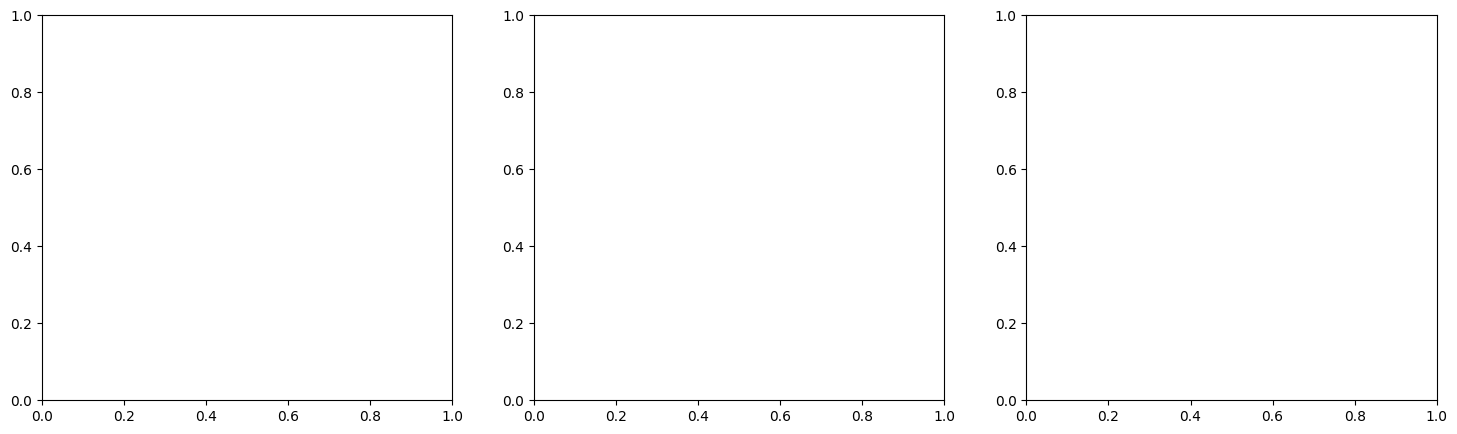

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12: Per-Class Accuracy Breakdown
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# We already have test_preds, test_labels from Cell 11
# If not, reload:
# test_preds, test_labels, test_probs = tta_predict(model_aug, test_dataset, DEVICE)

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Recall (row-normalized)
cm_precision = cm.astype(float) / (cm.sum(axis=0, keepdims=True) + 1e-8)  # Precision (col-normalized)

print("="*70)
print("  PER-CLASS METRICS (Test Set)")
print("="*70)
print(f"{'Class':<6} {'Support':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Accuracy':>10}")
print("-"*70)

for i, cls in enumerate(CLASSES):
    tp = cm[i, i]                    # True positives
    fp = cm[:, i].sum() - tp         # False positives
    fn = cm[i, :].sum() - tp         # False negatives
    tn = cm.sum() - tp - fp - fn     # True negatives

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / cm.sum()  # Per-class accuracy = (TP+TN)/Total

    support = cm[i, :].sum()

    print(f"{cls:<6} {support:>8} {precision:>10.3f} {recall:>8.3f} {f1:>8.3f} {accuracy:>10.3f}")

print("-"*70)
print(f"{'Overall':<6} {cm.sum():>8} {'(macro avg)':>10} {'':>8} {'':>8} {test_acc(torch.tensor(test_preds), torch.tensor(test_labels)):.4f}")

# Also show the standard classification report for reference
print("\n" + "="*70)
print("  STANDARD CLASSIFICATION REPORT (for reference)")
print("="*70)
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

# Visual comparison: Per-class metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = {
    "Precision": [cm_precision[i, i] for i in range(7)],
    "Recall": [cm_norm[i, i] for i in range(7)],
    "F1": [2*cm_precision[i,i]*cm_norm[i,i]/(cm_precision[i,i]+cm_norm[i,i]+1e-8) for i in range(7)]
}

colors = ["#e74c3c" if v < 0.60 else "#f39c12" if v < 0.75 else "#2ecc71" for _ in range(7)]

for ax, (name, vals) in zip(axes, metrics.items()):
    bars = ax.bar(CLASSES, vals, color=colors, edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
    ax.axhline(0.75, color="blue", linestyle="--", linewidth=1)
    ax.axhline(0.90, color="purple", linestyle="--", linewidth=1)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Per-Class {name}", fontweight="bold", fontsize=13)
    ax.set_ylabel(name)

plt.suptitle("Augmented Model + TTA | Test Set Per-Class Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/varicose_checkpoints_augmented/per_class_metrics.png", dpi=150)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 13: Merge v1 + v2 Datasets and Retrain
# ═══════════════════════════════════════════════════════════════

import os, shutil
from pathlib import Path

# Paths
V1_ROOT = "/content/drive/MyDrive/varicose_dataset/Varicose-Veins-Classification-1"
V2_ROOT = "/content/drive/MyDrive/varicose_dataset_augmented/Varicose-Veins-Classification-2"
MERGED_ROOT = "/content/drive/MyDrive/varicose_dataset_merged"
CHECKPOINT_DIR = "/content/drive/MyDrive/varicose_checkpoints_merged"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CLASSES = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

# ── 13.1 Create merged structure ──────────────────────────────
# Use v2's val and test (same as v1), but merge train folders
for split in ["train", "valid", "test"]:
    for cls in CLASSES:
        os.makedirs(Path(MERGED_ROOT) / split / cls, exist_ok=True)

# Copy v2 val and test (unchanged)
print("Copying val/test from v2...")
for split in ["valid", "test"]:
    for cls in CLASSES:
        src = Path(V2_ROOT) / split / cls
        dst = Path(MERGED_ROOT) / split / cls
        for f in src.glob("*"):
            shutil.copy2(f, dst)

# Merge train: copy v1 first, then v2 (v2 files may overwrite if same name, but that's fine)
print("Merging train folders (v1 + v2)...")
for cls in CLASSES:
    # Copy v1 train
    src1 = Path(V1_ROOT) / "train" / cls
    dst = Path(MERGED_ROOT) / "train" / cls
    if src1.exists():
        for f in src1.glob("*"):
            shutil.copy2(f, dst)

    # Copy v2 train (additional augmentations)
    src2 = Path(V2_ROOT) / "train" / cls
    if src2.exists():
        for f in src2.glob("*"):
            # Rename to avoid overwrite: add _v2 suffix if same name
            dst_file = dst / f.name
            if dst_file.exists():
                new_name = f.stem + "_v2" + f.suffix
                dst_file = dst / new_name
            shutil.copy2(f, dst_file)

# ── 13.2 Verify merged dataset ────────────────────────────────
print(f"\n{'='*50}")
print("MERGED DATASET VERIFICATION")
print(f"{'='*50}")
for split in ["train", "valid", "test"]:
    split_path = Path(MERGED_ROOT) / split
    counts = {}
    for cls in CLASSES:
        cls_dir = split_path / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    total = sum(counts.values())
    print(f"  ✅ {split:5s}: {total:4d} images  |  {counts}")

# ── 13.3 Update CONFIG for merged dataset ─────────────────────
CONFIG = {
    "data_root":       MERGED_ROOT,
    "checkpoint_dir":  CHECKPOINT_DIR,
    "classes":         CLASSES,
    "num_classes":     7,
    "img_size":        224,
    "batch_size":      32,
    "epochs_frozen":   5,
    "epochs_unfrozen": 50,
    "lr_head":         1e-3,
    "lr_backbone":     1e-4,
    "weight_decay":    1e-4,
    "label_smoothing": 0.1,
    "backbone":        "tf_efficientnetv2_s",
    "drop_rate":       0.3,
    "focal_gamma":     2.0,
    "grad_clip":       1.0,
    "patience":        12,
    "seed":            42,
    "device":          DEVICE,
}

# ── 13.4 Recreate datasets and loaders ────────────────────────
train_dataset = CEAPDataset(CONFIG["data_root"], "train", TRAIN_TRANSFORMS)
val_dataset   = CEAPDataset(CONFIG["data_root"], "valid", VAL_TRANSFORMS)
test_dataset  = CEAPDataset(CONFIG["data_root"], "test",  VAL_TRANSFORMS)

labels = train_dataset.get_labels()
counts = Counter(labels)
total = len(labels)

sample_weights = [np.sqrt(1.0 / counts[l]) for l in labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ DataLoaders ready | Train: {len(train_loader)} batches")

# ── 13.5 Class weights ────────────────────────────────────────
raw_weights = [total / (CONFIG["num_classes"] * counts[i]) for i in range(CONFIG["num_classes"])]
class_weights = torch.FloatTensor([min(w, 5.0) for w in raw_weights]).to(DEVICE)

print("\nMerged class weights:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {class_weights[i]:.3f}  (n={counts[i]})")

criterion = FocalLoss(alpha=class_weights, gamma=CONFIG["focal_gamma"], smoothing=CONFIG["label_smoothing"])

# ── 13.6 Fresh model and train ────────────────────────────────
model = CEAPClassifier(num_classes=7, backbone="tf_efficientnetv2_s", drop_rate=0.3).to(DEVICE)

print("\n" + "="*60)
print("  STARTING TRAINING ON MERGED DATASET (v1 + v2)")
print(f"  Total training images: {total}")
print("="*60)

model, history = train_model()

Copying val/test from v2...


In [ ]:
# Keep Colab alive - run this in SEPARATE cell, keep tab open
import time
from IPython.display import Javascript

def keep_alive():
    display(Javascript('''
        function ClickConnect(){
            console.log("Keeping alive...");
            document.querySelector("colab-connect-button").click()
        }
        setInterval(ClickConnect, 60000)
    '''))

keep_alive()
print("✅ Keep-alive active. Tab must stay open. Laptop must stay plugged in.")

<IPython.core.display.Javascript object>

✅ Keep-alive active. Tab must stay open. Laptop must stay plugged in.
